```sh
pip install pandas numpy matplotlib
```

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [ ]:
# Load CSV file
df = pd.read_csv('data/2026-05-04_072842.csv')
print(df.head())

   Unnamed: 0                                Food Collected Grid  \
0           0  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...   
1           1  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...   
2           2  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...   
3           3  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...   
4           4  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...   

                                      Pheromone Grid  Total Pheromone  \
0  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...              0.0   
1  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...              0.0   
2  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...              0.0   
3  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...              0.0   
4  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...              0.0   

   Average Energy  Food Collected  Dead  Resting  Foraging  Returning Loaded  \
0           199.7             0.0     0        0        50              

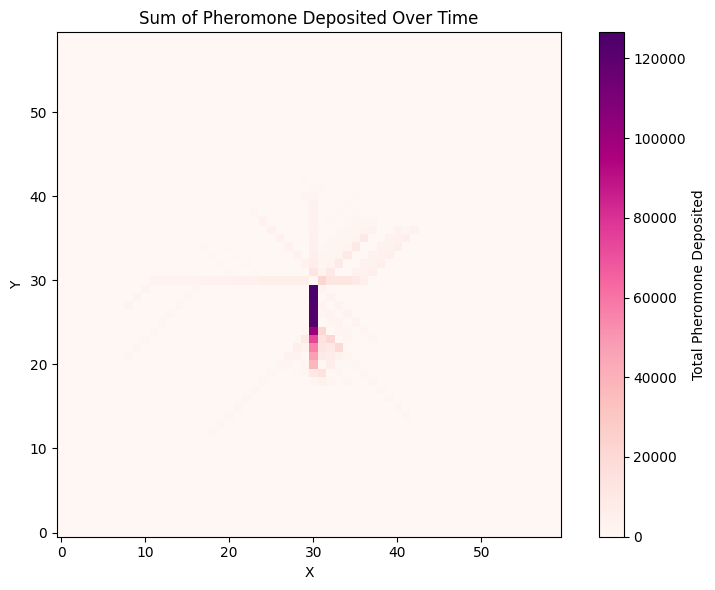

In [28]:
# Parse and sum the pheromone grids
pheromone_sum = None
for grid_str in df["Pheromone Grid"].dropna():
    # Convert string to numpy array
    grid = np.array(ast.literal_eval(grid_str))
    if pheromone_sum is None:
        pheromone_sum = np.zeros_like(grid)
    pheromone_sum += grid

# Plot the summed heatmap
plt.figure(figsize=(8, 6))
plt.imshow(pheromone_sum.T, cmap="RdPu", origin="lower")
plt.colorbar(label="Total Pheromone Deposited")
plt.title("Sum of Pheromone Deposited Over Time")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

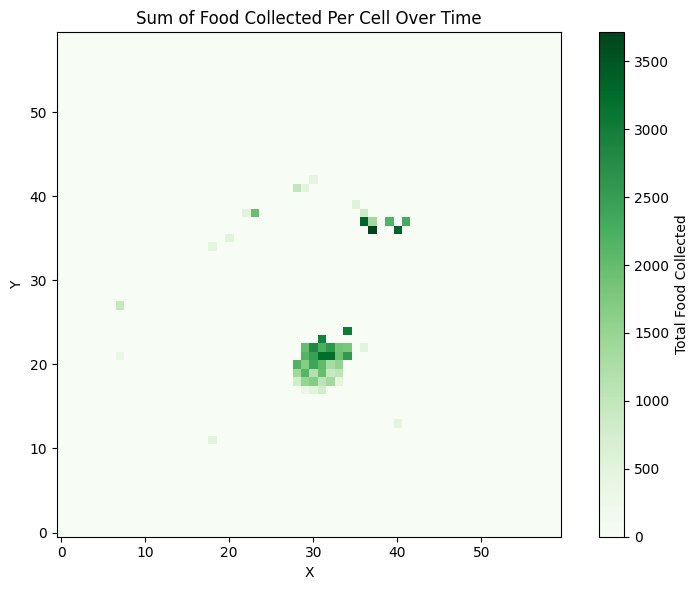

In [29]:
food_sum = None
for grid_str in df["Food Collected Grid"].dropna():
    grid = np.array(ast.literal_eval(grid_str))
    if food_sum is None:
        food_sum = np.zeros_like(grid)
    food_sum += grid

plt.figure(figsize=(8, 6))
plt.imshow(food_sum.T, cmap="Greens", origin="lower")
plt.colorbar(label="Total Food Collected")
plt.title("Sum of Food Collected Per Cell Over Time")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()